# QM9 Partition Interpretability with Buhito

This notebook is the Buhito-adapted version of the original MinervaChem workflow.

Key changes:

- `GraphletFingerprinter` / `FingerprintFeaturizer` → Buhito `BFSGraphletFeaturizer` + `GraphletTransformer`.
- RDKit molecules are retained for chemistry-aware partitioning and visualization, while Buhito NetworkX graphs are used for graphlet featurization.
- `GraphletDAG` and `draw_projected_coefs` are removed.
- The fitted linear model is a standard `Ridge` model whose coefficient vector aligns directly with `featurizer.bit_ids_`.
- Every molecule used by `PartitionInterpreter` is explicitly registered with its corresponding Buhito graph.
- Partition visualization uses `partition_visualization.py`, which operates directly on RDKit molecules and `PartitionInterpretation` objects.

**Required local files:** `partition_interpretability.py`, `partition_visualization.py`, and `qm9_processed.csv`.

In [1]:
import sys
from pathlib import Path

repo_root = Path.cwd().resolve().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Repository root:", repo_root)

import io
import re
import time
import contextlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from rdkit import Chem

from buhito.featurizers.bfs_graphlet_featurizer import BFSGraphletFeaturizer
from buhito.transformers import GraphletTransformer
from buhito.converters import smiles_to_nx

warnings.filterwarnings("ignore")
%matplotlib inline
%load_ext autoreload
%autoreload 2

print("✓ Buhito imports successful")

Repository root: /Users/lucyliu/Documents/buhito


Matplotlib is building the font cache; this may take a moment.
/Users/lucyliu/anaconda3/envs/buhito_env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Buhito imports successful


## 1. Preprocess QM9

Create both representations needed by the workflow:

- `mol`: RDKit molecule with explicit hydrogens.
- `graph`: Buhito/NetworkX graph generated from the same SMILES with explicit hydrogens.

Using the same hydrogen convention is important because the Buhito graph node IDs must match the RDKit atom indices used by the partition interpreter.

In [ ]:
from pathlib import Path

In [6]:

def smiles_to_buhito_graph(smiles, add_hs=True, output_2d_pos=False):
    result = smiles_to_nx(
        smiles,
        add_hs=add_hs,
        output_2d_pos=output_2d_pos,
    )
    return result[0] if isinstance(result, (tuple, list)) else result


df = pd.read_csv(
    "../examples/qm9/qm9data/qm9_processed.csv"
)
print("Data frame shape:", df.shape)

start = time.time()
df["mol"] = df["smiles"].map(
    lambda s: Chem.AddHs(Chem.MolFromSmiles(s))
)
df["graph"] = df["smiles"].map(
    lambda s: smiles_to_buhito_graph(s, add_hs=True, output_2d_pos=False)
)
print(f"Created RDKit molecules + Buhito graphs in {time.time() - start:.2f} s")

# Verify node-index alignment on a few examples.
for idx in range(min(5, len(df))):
    mol = df.iloc[idx]["mol"]
    graph = df.iloc[idx]["graph"]
    assert set(map(int, graph.nodes)) == set(range(mol.GetNumAtoms()))

print("✓ Buhito graph node IDs match RDKit atom indices")
df[["smiles", "E_at"]].head()

Data frame shape: (130831, 19)
Created RDKit molecules + Buhito graphs in 21.54 s
✓ Buhito graph node IDs match RDKit atom indices


,smiles,E_at
0,C,-395.999894
1,N,-276.861573
2,O,-213.087785
3,C#C,-385.502288
4,C#N,-301.820762


## 2. Train/test split and Buhito graphlet features

The Buhito transformer is fit on NetworkX graphs, not RDKit molecules.

In [7]:
train, test = train_test_split(
    df,
    train_size=0.8,
    random_state=42,
)

print(f"Training set: {len(train)} molecules")
print(f"Test set:     {len(test)} molecules")

base_graphlet_featurizer = BFSGraphletFeaturizer(
    return_nodewise=False,
    max_len=5,
)

featurizer = GraphletTransformer(
    featurizer=base_graphlet_featurizer,
    verbose=0,
    n_jobs=-1,
    chunk_size="auto",
)

start = time.time()
X_train = featurizer.fit_transform(train["graph"].tolist())
X_test = featurizer.transform(test["graph"].tolist())
print(f"Buhito featurization time: {time.time() - start:.2f} s")

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("Number of fitted graphlet bits:", len(featurizer.bit_ids_))
print("Max fitted graphlet size:", int(np.max(featurizer.bit_sizes_)))

Training set: 104664 molecules
Test set:     26167 molecules
Buhito featurization time: 103.45 s
X_train shape: (104664, 5370)
X_test shape:  (26167, 5370)
Number of fitted graphlet bits: 5370
Max fitted graphlet size: 5


## 3. Ridge graphlet model

The original notebook used MinervaChem's `HierarchicalResidualModel`. That class is MinervaChem-specific. For the Buhito partition decomposition, the important requirement is a fitted model with one coefficient per Buhito graphlet feature, so this notebook uses the Ridge graphlet model directly.

In [8]:
y_train = train["E_at"].to_numpy()
y_test = test["E_at"].to_numpy()

model = Ridge(
    fit_intercept=False,
    alpha=1e-5,
    solver="sparse_cg",
    tol=1e-5,
)

start = time.time()
model.fit(X_train, y_train)
print(f"Training time: {time.time() - start:.2f} s")

assert len(np.asarray(model.coef_).reshape(-1)) == len(featurizer.bit_ids_)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("=" * 60)
print("BUHITO GRAPHLET RIDGE PERFORMANCE")
print("=" * 60)
print(f"Train R²:   {train_r2:.4f}")
print(f"Test R²:    {test_r2:.4f}")
print(f"Train MAE:  {train_mae:.2f} kcal/mol")
print(f"Test MAE:   {test_mae:.2f} kcal/mol")
print(f"Train RMSE: {train_rmse:.2f} kcal/mol")
print(f"Test RMSE:  {test_rmse:.2f} kcal/mol")

Training time: 1.18 s
BUHITO GRAPHLET RIDGE PERFORMANCE
Train R²:   0.9993
Test R²:    0.9993
Train MAE:  3.76 kcal/mol
Test MAE:   3.81 kcal/mol
Train RMSE: 6.16 kcal/mol
Test RMSE:  6.26 kcal/mol


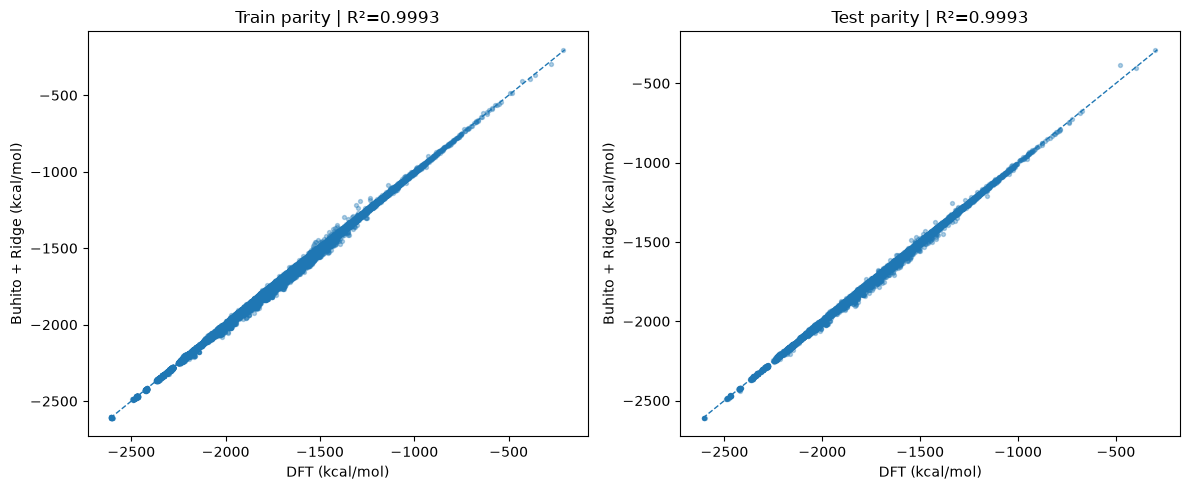

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_train, y_train_pred, s=8, alpha=0.35)
lo = min(y_train.min(), y_train_pred.min())
hi = max(y_train.max(), y_train_pred.max())
axes[0].plot([lo, hi], [lo, hi], "--", linewidth=1)
axes[0].set_title(f"Train parity | R²={train_r2:.4f}")
axes[0].set_xlabel("DFT (kcal/mol)")
axes[0].set_ylabel("Buhito + Ridge (kcal/mol)")

axes[1].scatter(y_test, y_test_pred, s=8, alpha=0.35)
lo = min(y_test.min(), y_test_pred.min())
hi = max(y_test.max(), y_test_pred.max())
axes[1].plot([lo, hi], [lo, hi], "--", linewidth=1)
axes[1].set_title(f"Test parity | R²={test_r2:.4f}")
axes[1].set_xlabel("DFT (kcal/mol)")
axes[1].set_ylabel("Buhito + Ridge (kcal/mol)")

plt.tight_layout()
plt.show()

## 4. Inspect coefficient magnitude by graphlet size

This replaces the MinervaChem `hmodel.plot_coefs()` diagnostic. It does not reproduce the hierarchical residual model; it simply summarizes the fitted Ridge coefficients according to Buhito's `bit_sizes_`.

,count,mean,median,max
Graphlet Size,,,,
1,9,42.757035,24.788446,118.498657
2,40,9.203071,7.820644,27.017412
3,194,2.619611,1.708359,19.448822
4,939,0.998576,0.564242,10.537506
5,4188,0.544203,0.302005,7.194987


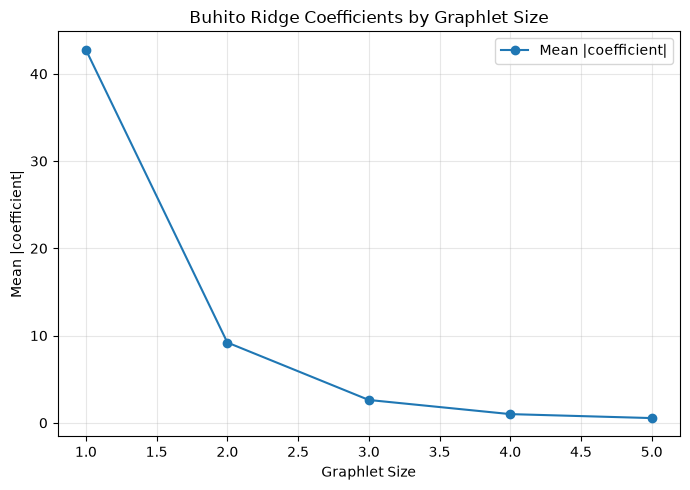

In [10]:
coef_df = pd.DataFrame({
    "Graphlet Size": np.asarray(featurizer.bit_sizes_, dtype=int),
    "Coefficient": np.asarray(model.coef_, dtype=float).reshape(-1),
})
coef_df["Abs Coefficient"] = coef_df["Coefficient"].abs()

coef_summary = (
    coef_df.groupby("Graphlet Size")["Abs Coefficient"]
    .agg(["count", "mean", "median", "max"])
)
display(coef_summary)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(
    coef_summary.index,
    coef_summary["mean"],
    marker="o",
    label="Mean |coefficient|",
)
ax.set_xlabel("Graphlet Size")
ax.set_ylabel("Mean |coefficient|")
ax.set_title("Buhito Ridge Coefficients by Graphlet Size")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 5. Partition-based interpretability setup

`PartitionInterpreter` is now Buhito-specific. It uses `featurizer.bit_ids_`, `featurizer.bit_sizes_`, and the graphlet-instance information generated during `GraphletTransformer.transform()`.

A required step is `interpreter.register_graph(mol, graph)` for every molecule that will be decomposed.

In [ ]:
import importlib
import partition_interpretability
import partition_visualization

importlib.reload(partition_interpretability)
importlib.reload(partition_visualization)

from partition_interpretability import (
    PartitionInterpreter,
    PartitionOptimizer,
    ChemicalPartitioner,
    visualize_partition_comparison,
    partition_connectivity_penalty,
    connectivity_adjusted_score,
    validate_partition_decomposition,
)

from partition_visualization import (
    build_graphlet_dag_from_buhito,
    draw_projected_coefs_with_partitions,
    draw_buhito_partition_interpretations,
)

interpreter_full = PartitionInterpreter(
    featurizer=featurizer,
    model=model,
    remove_single_atom_contributions=False,
)

interpreter_no_atoms = PartitionInterpreter(
    featurizer=featurizer,
    model=model,
    remove_single_atom_contributions=True,
)

interpreter = interpreter_full

print("✓ PartitionInterpreter initialized for Buhito")
print("Graphlet types:", len(featurizer.bit_ids_))
print("Model coefficients:", len(np.asarray(model.coef_).reshape(-1)))
print("Single-atom features:", len(interpreter_no_atoms.atom_level_indices))

✓ PartitionInterpreter initialized for Buhito
Graphlet types: 5370
Model coefficients: 5370
Single-atom features: 9


In [15]:
def register_dataframe_graphs(interpreter_obj, frame):
    """Register each RDKit molecule with its already-created Buhito graph."""
    for mol, graph in zip(frame["mol"], frame["graph"]):
        interpreter_obj.register_graph(mol, graph)


# Register the test set for both interpreter modes.
register_dataframe_graphs(interpreter_full, test)
register_dataframe_graphs(interpreter_no_atoms, test)
print("✓ Test-set Buhito graphs registered")

✓ Test-set Buhito graphs registered


## 6. Select small, medium, and large test molecules

In [28]:
test_reset = test.reset_index(drop=True)

small_idx = test_reset[
    test_reset["mol"].apply(lambda m: m.GetNumAtoms() < 8)
].index[0]

medium_idx = test_reset[
    test_reset["mol"].apply(lambda m: 8 <= m.GetNumAtoms() < 12)
].index[0]

large_idx = test_reset[
    test_reset["mol"].apply(lambda m: m.GetNumAtoms() >= 12)
].index[0]

selected_rows = [
    test_reset.loc[small_idx],
    test_reset.loc[medium_idx],
    test_reset.loc[large_idx],
]

selected_mols = [
    (row["mol"], row["smiles"], label)
    for row, label in zip(selected_rows, ["Small", "Medium", "Large"])
]

# The test set was already registered, but this makes the dependency explicit.
for row in selected_rows:
    interpreter_full.register_graph(row["mol"], row["graph"])
    interpreter_no_atoms.register_graph(row["mol"], row["graph"])

for row, (_, smiles, size_label) in zip(selected_rows, selected_mols):
    pred = model.predict(featurizer.transform([row["graph"]]))[0]
    actual = row["E_at"]
    print(f"[{size_label}] {smiles}")
    print(f"  Atoms: {row['mol'].GetNumAtoms()}, bonds: {row['mol'].GetNumBonds()}")
    print(f"  Predicted: {pred:.2f} kcal/mol")
    print(f"  Actual:    {actual:.2f} kcal/mol")
    print(f"  Error:     {abs(pred - actual):.2f} kcal/mol\n")

[Small] FC(F)(F)F
  Atoms: 5, bonds: 4
  Predicted: -383.36 kcal/mol
  Actual:    -478.90 kcal/mol
  Error:     95.55 kcal/mol

[Medium] O=C1NN=CN=C1
  Atoms: 10, bonds: 10
  Predicted: -1043.72 kcal/mol
  Actual:    -1041.95 kcal/mol
  Error:     1.77 kcal/mol

[Large] COC12CC1OC2CO
  Atoms: 19, bonds: 20
  Predicted: -1764.76 kcal/mol
  Actual:    -1767.24 kcal/mol
  Error:     2.48 kcal/mol



## 7. Compare baseline and greedy partitioning methods

In [29]:
def compare_with_greedy(
    mol,
    interpreter,
    smiles="",
    k_values=(2, 3, 4),
    greedy_iters=100,
    connectivity_weight=0.10,
    disconnected_singleton_weight=2.0,
    verbose=True,
):
    results = []

    def store_result(strategy, method, k, interpretation):
        partition = interpretation.partition
        breakdown = interpretation.get_contribution_breakdown()

        penalty = partition_connectivity_penalty(
            mol=mol,
            partition=partition,
            disconnected_singleton_weight=disconnected_singleton_weight,
        )
        adjusted = connectivity_adjusted_score(
            mol=mol,
            interpretation=interpretation,
            connectivity_weight=connectivity_weight,
            disconnected_singleton_weight=disconnected_singleton_weight,
        )

        results.append({
            "Strategy": strategy,
            "Method": method,
            "k": k,
            "N_partitions": len(set(partition.values())),
            "Score": interpretation.score,
            "Connectivity Penalty": penalty,
            "Adjusted Score": adjusted,
            "Within %": 100 * breakdown["within_frac"],
            "Between %": 100 * breakdown["between_frac"],
            "Higher %": 100 * breakdown["higher_frac"],
            "Interpretation": interpretation,
        })

    for k in k_values:
        p = ChemicalPartitioner.distance_partition(mol, n_clusters=k, seed=42)
        store_result(
            f"Distance (k={k})", "Distance", k,
            interpreter.compute_partition_contributions(mol, p),
        )

        p = ChemicalPartitioner.random_partition(mol, n_clusters=k, seed=42)
        store_result(
            f"Random (k={k})", "Random", k,
            interpreter.compute_partition_contributions(mol, p),
        )

        optimizer_k = PartitionOptimizer(
            interpreter=interpreter,
            min_partitions=k,
            max_partitions=k,
            connectivity_weight=connectivity_weight,
            disconnected_singleton_weight=disconnected_singleton_weight,
        )

        store_result(
            f"Greedy-Random (k={k})", "Greedy-Random", k,
            optimizer_k.optimize_partition_random(
                mol=mol,
                n_iterations=greedy_iters,
                seed=42,
                verbose=False,
            ),
        )

        store_result(
            f"Greedy-Distance (k={k})", "Greedy-Distance", k,
            optimizer_k.optimize_partition_distance(
                mol=mol,
                n_clusters=k,
                n_iterations=greedy_iters,
                seed=42,
                verbose=False,
            ),
        )

    results.sort(key=lambda r: r["Adjusted Score"], reverse=True)

    if verbose:
        print(f"\n{smiles}")
        for r in results[:8]:
            print(
                f"{r['Strategy']:25s} "
                f"raw={r['Score']:.4f} "
                f"penalty={r['Connectivity Penalty']:.4f} "
                f"adjusted={r['Adjusted Score']:.4f}"
            )

    return results


FC(F)(F)F
Distance (k=2)            raw=0.9144 penalty=0.0000 adjusted=0.9144
Greedy-Random (k=2)       raw=0.9144 penalty=0.0000 adjusted=0.9144
Greedy-Distance (k=2)     raw=0.9144 penalty=0.0000 adjusted=0.9144
Greedy-Random (k=3)       raw=0.8289 penalty=0.0000 adjusted=0.8289
Distance (k=3)            raw=0.8289 penalty=0.0000 adjusted=0.8289
Greedy-Distance (k=3)     raw=0.8289 penalty=0.0000 adjusted=0.8289
Random (k=2)              raw=0.8518 penalty=0.4000 adjusted=0.8118
Distance (k=4)            raw=0.7479 penalty=0.0000 adjusted=0.7479


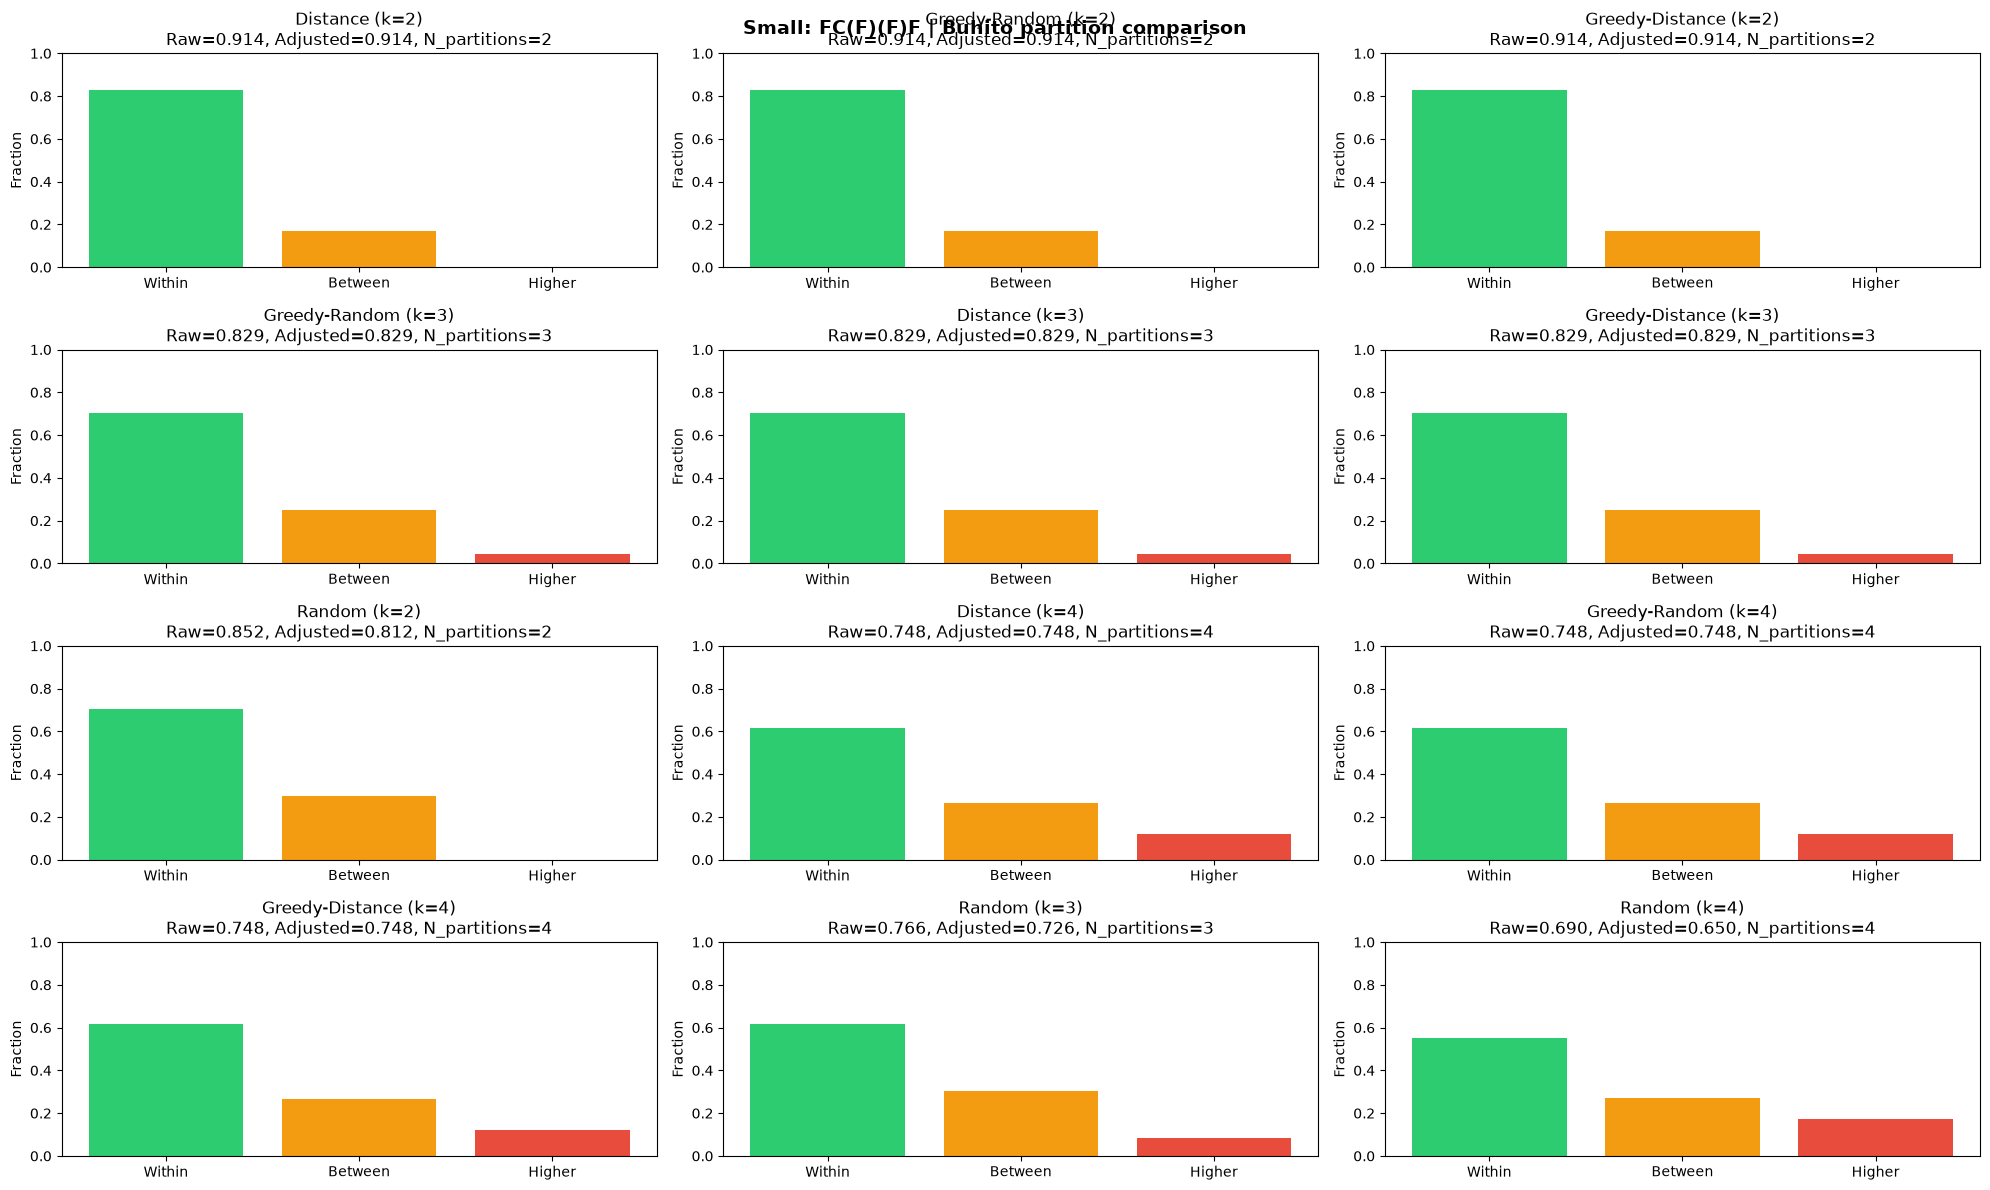


O=C1NN=CN=C1
Greedy-Random (k=2)       raw=0.9785 penalty=0.0000 adjusted=0.9785
Greedy-Random (k=3)       raw=0.9680 penalty=0.0000 adjusted=0.9680
Greedy-Distance (k=3)     raw=0.9680 penalty=0.0000 adjusted=0.9680
Distance (k=2)            raw=0.9673 penalty=0.0000 adjusted=0.9673
Greedy-Distance (k=2)     raw=0.9673 penalty=0.0000 adjusted=0.9673
Distance (k=3)            raw=0.9602 penalty=0.0000 adjusted=0.9602
Greedy-Random (k=4)       raw=0.9487 penalty=0.0000 adjusted=0.9487
Greedy-Distance (k=4)     raw=0.9381 penalty=0.0000 adjusted=0.9381


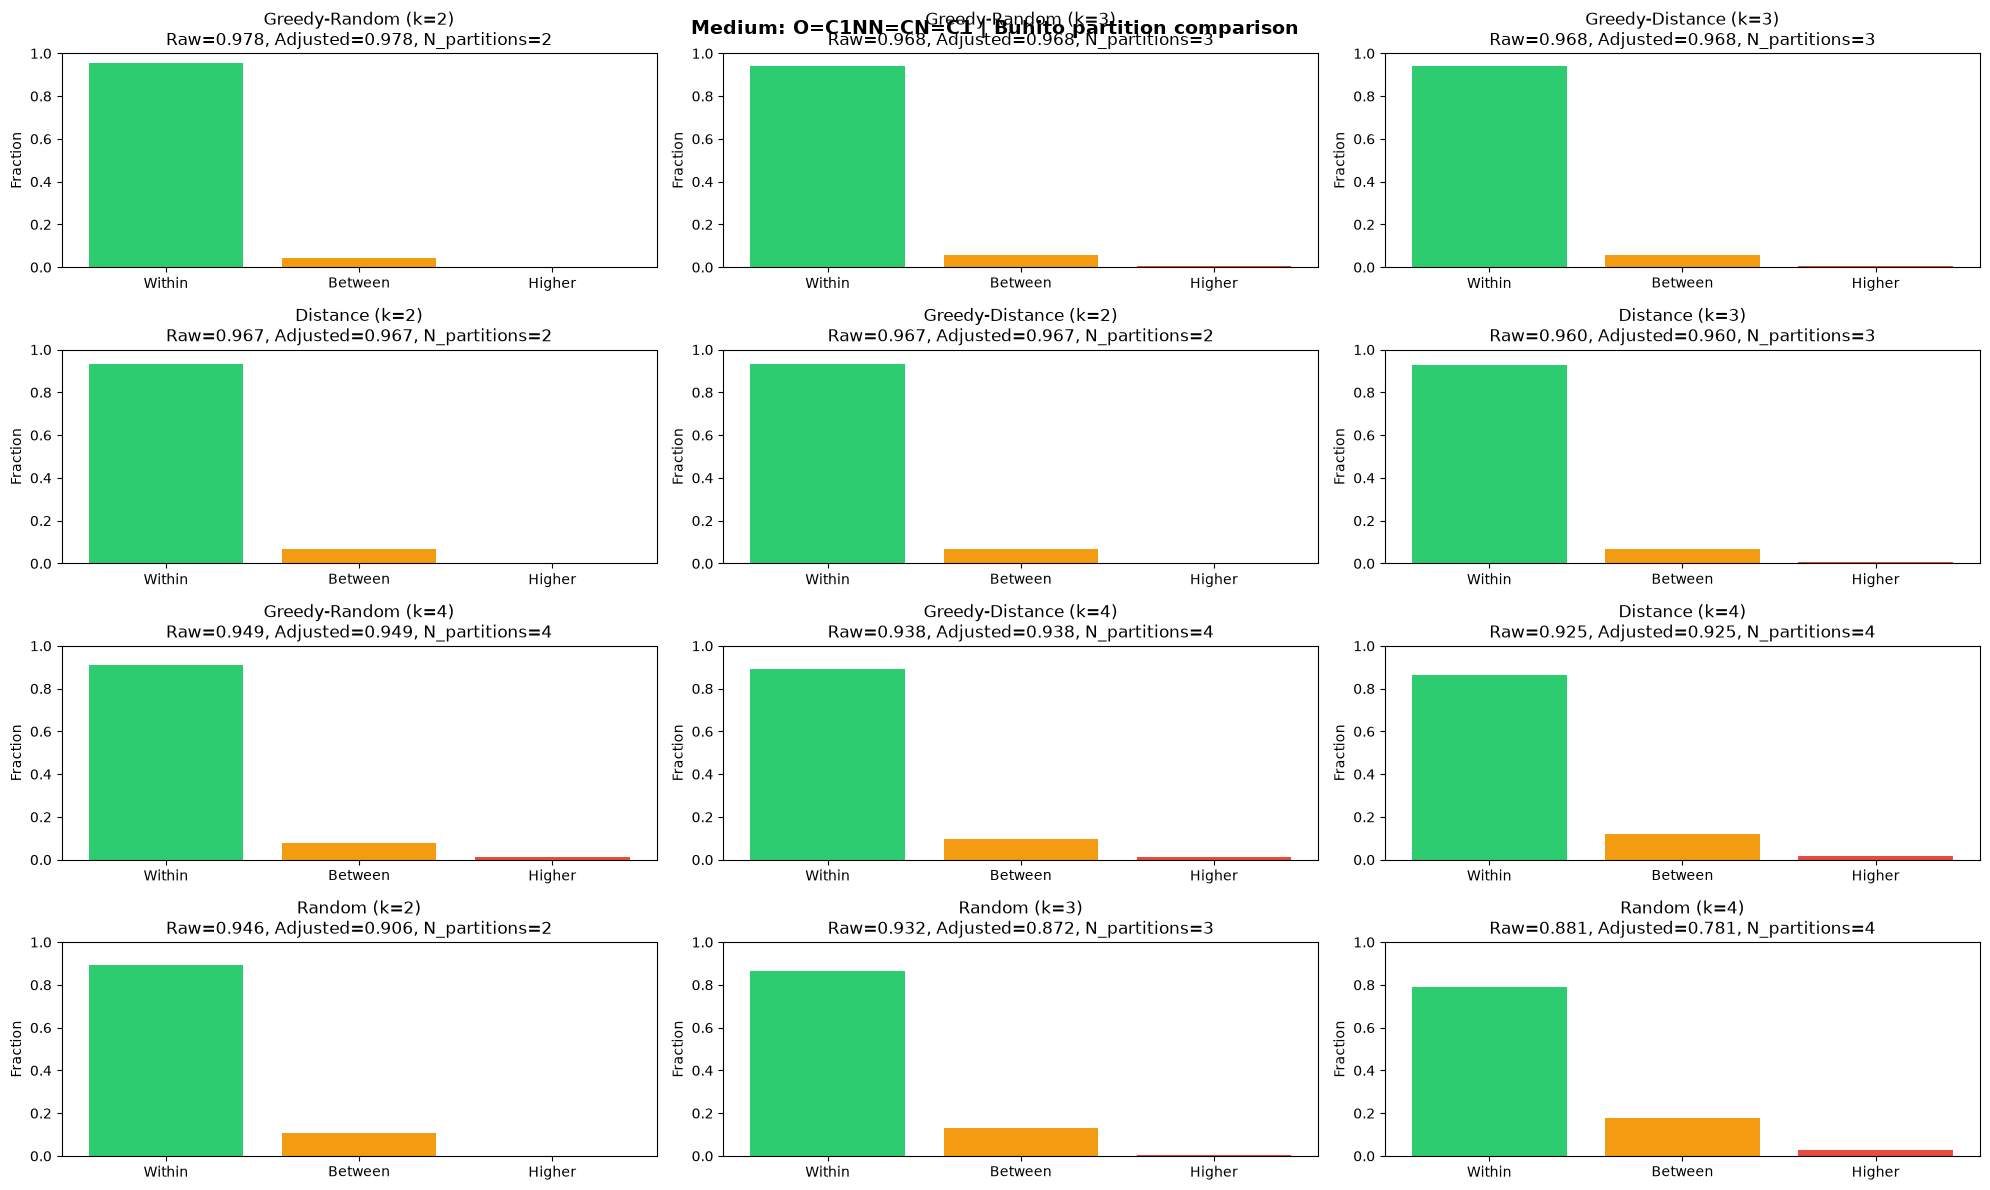


COC12CC1OC2CO
Distance (k=2)            raw=0.9961 penalty=0.0000 adjusted=0.9961
Greedy-Distance (k=2)     raw=0.9961 penalty=0.0000 adjusted=0.9961
Distance (k=3)            raw=0.9902 penalty=0.0000 adjusted=0.9902
Greedy-Distance (k=3)     raw=0.9902 penalty=0.0000 adjusted=0.9902
Greedy-Distance (k=4)     raw=0.9836 penalty=0.0000 adjusted=0.9836
Distance (k=4)            raw=0.9777 penalty=0.0000 adjusted=0.9777
Greedy-Random (k=3)       raw=0.9911 penalty=0.2105 adjusted=0.9700
Greedy-Random (k=2)       raw=0.9886 penalty=0.2105 adjusted=0.9676


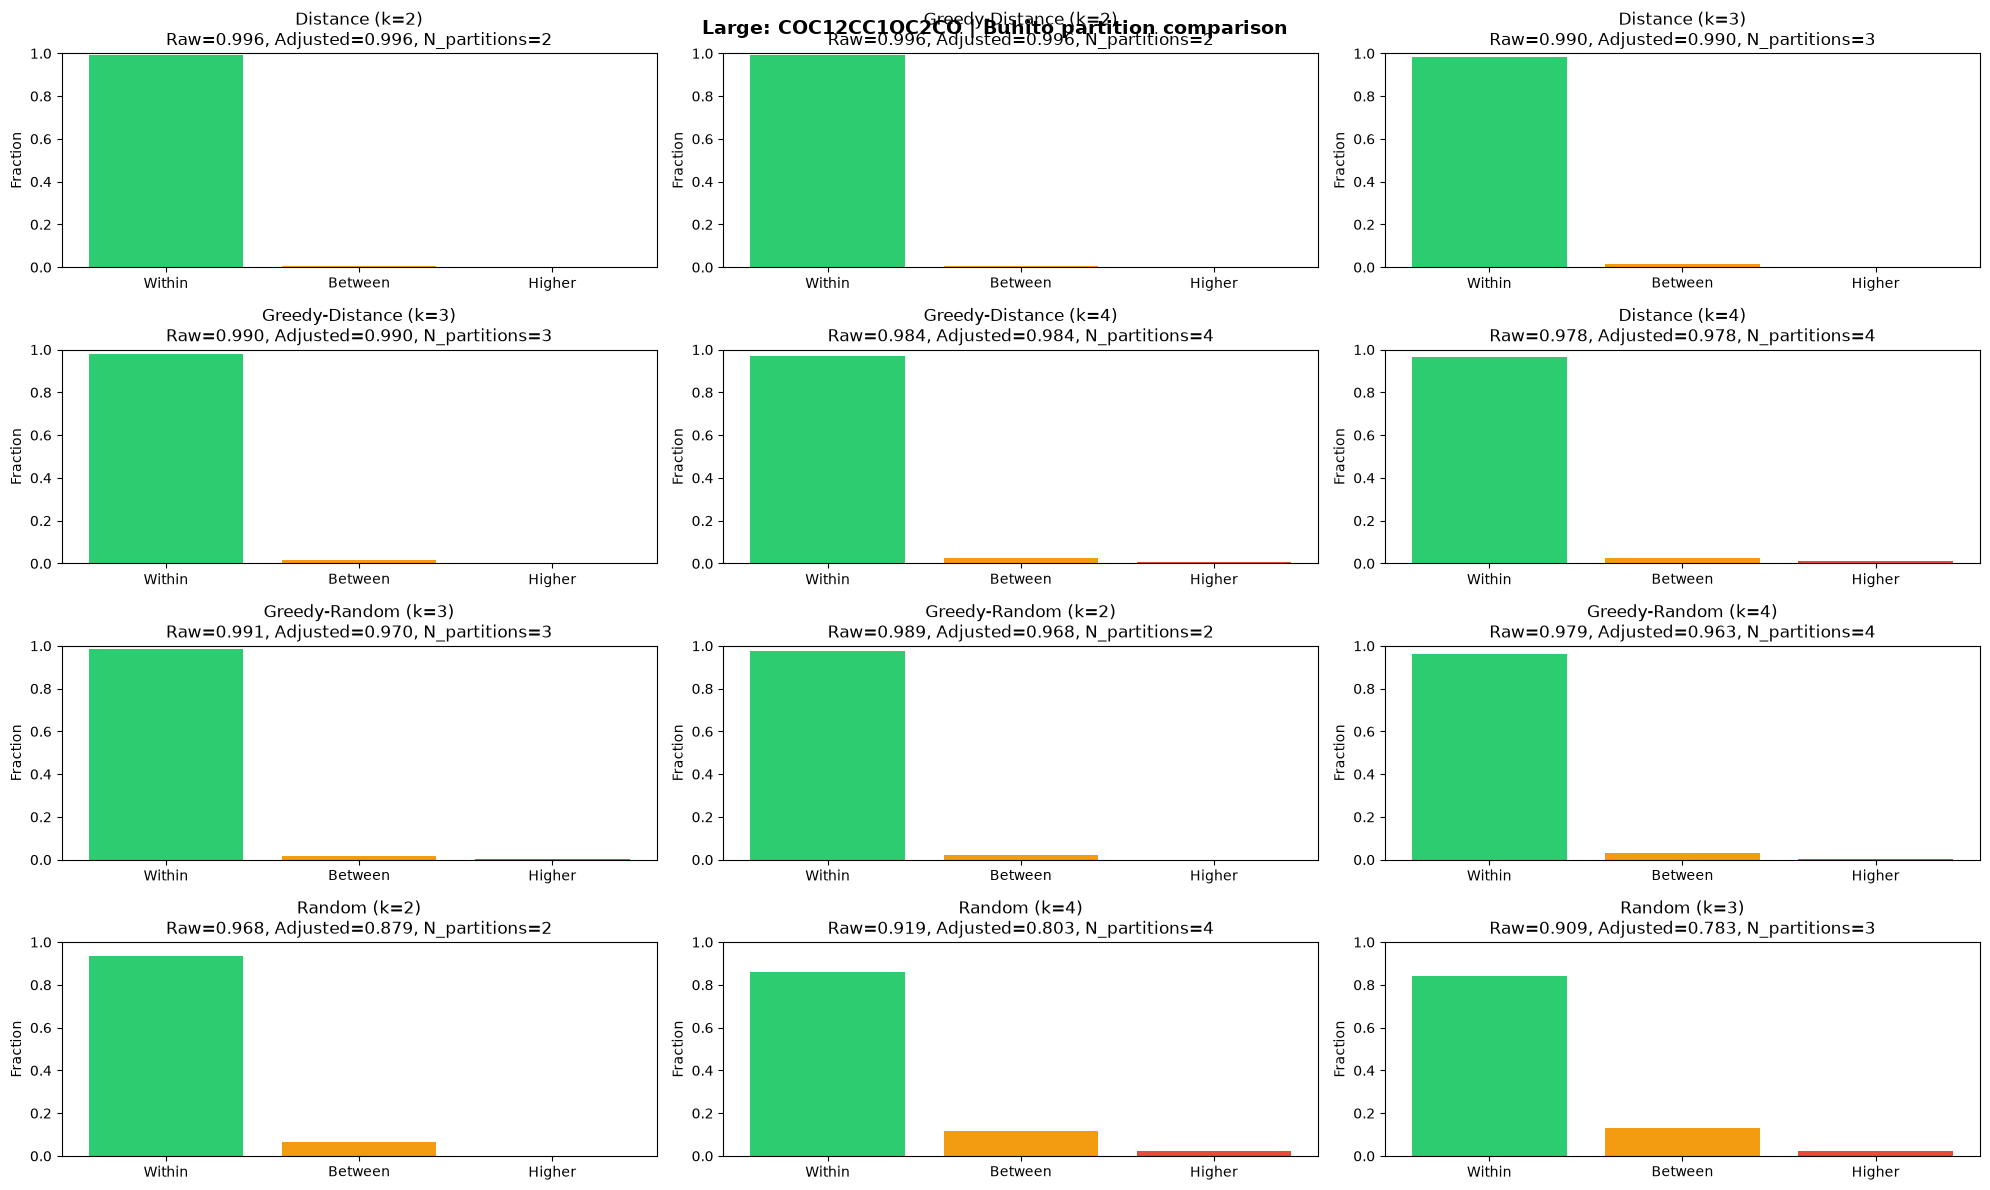

In [30]:
all_results = {}
k_values = [2, 3, 4]

for mol, smiles, size_label in selected_mols:
    results = compare_with_greedy(
        mol=mol,
        interpreter=interpreter,
        smiles=smiles,
        k_values=k_values,
        greedy_iters=100,
        connectivity_weight=0.10,
        disconnected_singleton_weight=2.0,
        verbose=True,
    )
    all_results[size_label] = results

    fig = visualize_partition_comparison(mol, results, figsize=(20, 12))
    plt.suptitle(
        f"{size_label}: {smiles} | Buhito partition comparison",
        fontsize=14,
        fontweight="bold",
    )
    plt.show()

## 8. Visualize partition interpretations

In [31]:
# =============================================================================
# 8. GRAPHLETDAG PARTITION VISUALIZATION
# =============================================================================

K_TO_PLOT = 2

for mol, smiles, size_label in selected_mols:

    selected_results = [
        result
        for result
        in all_results[size_label]
        if result["N_partitions"] == K_TO_PLOT
    ]

    selected_results.sort(
        key=lambda result: result["Adjusted Score"],
        reverse=True,
    )

    selected_results = selected_results[:6]

    interpretations = [
        result["Interpretation"]
        for result
        in selected_results
    ]

    titles = [
        (
            f"{result['Strategy']}\n"
            f"Raw={result['Score']:.4f} | "
            f"Adjusted={result['Adjusted Score']:.4f}"
        )
        for result
        in selected_results
    ]

    fig, axes = (
        draw_buhito_partition_interpretations(
            mols=[
                mol
                for _
                in interpretations
            ],
            interpretations=interpretations,
            interpreter=interpreter_full,
            level=1,
            ncol=3,
            figsize=(
                18,
                6 * (
                    (
                        len(interpretations)
                        + 2
                    )
                    // 3
                ),
            ),
            titles=titles,
            show_coefficients=True,
            show_atom_labels=False,
            show_atom_indices=True,
            dpi=150,
        )
    )

    fig.suptitle(
        (
            f"{size_label}: {smiles} | "
            f"k={K_TO_PLOT} | "
            "Buhito + GraphletDAG"
        ),
        fontsize=15,
        fontweight="bold",
        y=1.01,
    )

    plt.show()

NameError: name 'draw_buhito_partition_interpretations' is not defined

## 9. Validate the Buhito decomposition

For a valid registered molecule, the sum of within-, between-, and higher-order graphlet contributions should reproduce the active linear graphlet prediction (up to numerical tolerance).

In [ ]:
validation_rows = []

for mol, smiles, size_label in selected_mols:
    partition = ChemicalPartitioner.distance_partition(
        mol,
        n_clusters=2,
        seed=42,
    )
    result = validate_partition_decomposition(
        mol=mol,
        interpreter=interpreter,
        partition=partition,
        tolerance=1e-6,
    )
    validation_rows.append({
        "Size": size_label,
        "SMILES": smiles,
        "Passed": result["passed"],
        "Prediction": result["total_prediction"],
        "Sum of parts": result["sum_of_parts"],
        "Difference": result["difference"],
    })

validation_df = pd.DataFrame(validation_rows)
display(validation_df)

,Size,SMILES,Passed,Prediction,Sum of parts,Difference
0,Small,FC(F)(F)F,True,-383.357343,-383.357343,1.136868e-13
1,Medium,O=C1NN=CN=C1,True,-1043.715318,-1043.715318,2.273737e-13
2,Large,COC12CC1OC2CO,True,-1764.758870,-1764.758870,2.273737e-13


## 10. Metropolis-Hastings: score versus observed acceptance rate

This preserves the existing M-H implementation. Acceptance rate is extracted from its verbose output rather than changing the method itself.

In [ ]:
def extract_final_acceptance_rate(output_text):
    matches = re.findall(
        r"Acceptance rate:\s*([0-9]*\.?[0-9]+)",
        output_text,
        flags=re.IGNORECASE,
    )
    if not matches:
        raise RuntimeError("Could not find final M-H acceptance rate in verbose output.")
    return float(matches[-1])

In [ ]:
# Use the selected large molecule.
large_row = selected_rows[2]
large_mol = large_row["mol"]
large_graph = large_row["graph"]
large_smiles = large_row["smiles"]

# Explicit registration for clarity.
interpreter.register_graph(large_mol, large_graph)

K_TO_PLOT = 4
CONNECTIVITY_WEIGHT = 0.10
DISCONNECTED_SINGLETON_WEIGHT = 2.0
MH_BETAS = (0.1, 1.0, 5.0, 20.0, 50.0, 100.0)
MH_ITERATIONS = 5000
MH_INITIALIZATION = "distance"
N_INITIALIZATIONS = 100
BASE_SEED = 42
INITIALIZATION_SEEDS = [BASE_SEED + i for i in range(N_INITIALIZATIONS)]

mh_run_results = []

for mh_beta in MH_BETAS:
    print(f"\nBeta={mh_beta:g}")

    optimizer_beta = PartitionOptimizer(
        interpreter=interpreter,
        min_partitions=K_TO_PLOT,
        max_partitions=K_TO_PLOT,
        connectivity_weight=CONNECTIVITY_WEIGHT,
        disconnected_singleton_weight=DISCONNECTED_SINGLETON_WEIGHT,
    )

    for run_idx, seed in enumerate(INITIALIZATION_SEEDS, start=1):
        output_buffer = io.StringIO()
        with contextlib.redirect_stdout(output_buffer):
            interpretation = optimizer_beta.optimize_partition_metropolis_hastings(
                mol=large_mol,
                n_clusters=K_TO_PLOT,
                n_iterations=MH_ITERATIONS,
                beta=mh_beta,
                initialization=MH_INITIALIZATION,
                seed=seed,
                verbose=True,
            )

        acceptance_rate = extract_final_acceptance_rate(output_buffer.getvalue())
        partition = interpretation.partition
        penalty = partition_connectivity_penalty(
            mol=large_mol,
            partition=partition,
            disconnected_singleton_weight=DISCONNECTED_SINGLETON_WEIGHT,
        )
        adjusted = connectivity_adjusted_score(
            mol=large_mol,
            interpretation=interpretation,
            connectivity_weight=CONNECTIVITY_WEIGHT,
            disconnected_singleton_weight=DISCONNECTED_SINGLETON_WEIGHT,
        )

        mh_run_results.append({
            "Beta": mh_beta,
            "Initialization": run_idx,
            "Seed": seed,
            "Acceptance Rate": acceptance_rate,
            "Raw Score": interpretation.score,
            "Connectivity Penalty": penalty,
            "Adjusted Score": adjusted,
            "Partition": partition.copy(),
            "Interpretation": interpretation,
        })

        if run_idx % 20 == 0:
            print(f"  completed {run_idx}/{N_INITIALIZATIONS}")

mh_results_df = pd.DataFrame(mh_run_results)
print("Total runs:", len(mh_results_df))


Beta=0.1
  completed 20/100
  completed 40/100
  completed 60/100
  completed 80/100
  completed 100/100

Beta=1
  completed 20/100
  completed 40/100
  completed 60/100
  completed 80/100
  completed 100/100

Beta=5
  completed 20/100
  completed 40/100
  completed 60/100
  completed 80/100
  completed 100/100

Beta=20
  completed 20/100
  completed 40/100
  completed 60/100
  completed 80/100
  completed 100/100

Beta=50
  completed 20/100
  completed 40/100
  completed 60/100
  completed 80/100
  completed 100/100

Beta=100
  completed 20/100
  completed 40/100
  completed 60/100
  completed 80/100
  completed 100/100
Total runs: 600


,Beta,N,Mean_Acceptance_Rate,Std_Acceptance_Rate,Mean_Adjusted_Score,Std_Adjusted_Score,Min_Adjusted_Score,Max_Adjusted_Score
0,0.1,100,0.999236,0.000829,0.994451,0.001143,0.991126,0.996099
1,1.0,100,0.992361,0.002430,0.994429,0.001201,0.991036,0.996099
2,5.0,100,0.962641,0.005343,0.994555,0.001216,0.991068,0.996099
3,20.0,100,0.849532,0.012855,0.994551,0.001159,0.991057,0.996099
4,50.0,100,0.651697,0.025634,0.994452,0.001417,0.989338,0.996099
5,100.0,100,0.422441,0.059449,0.993902,0.001565,0.987414,0.996099


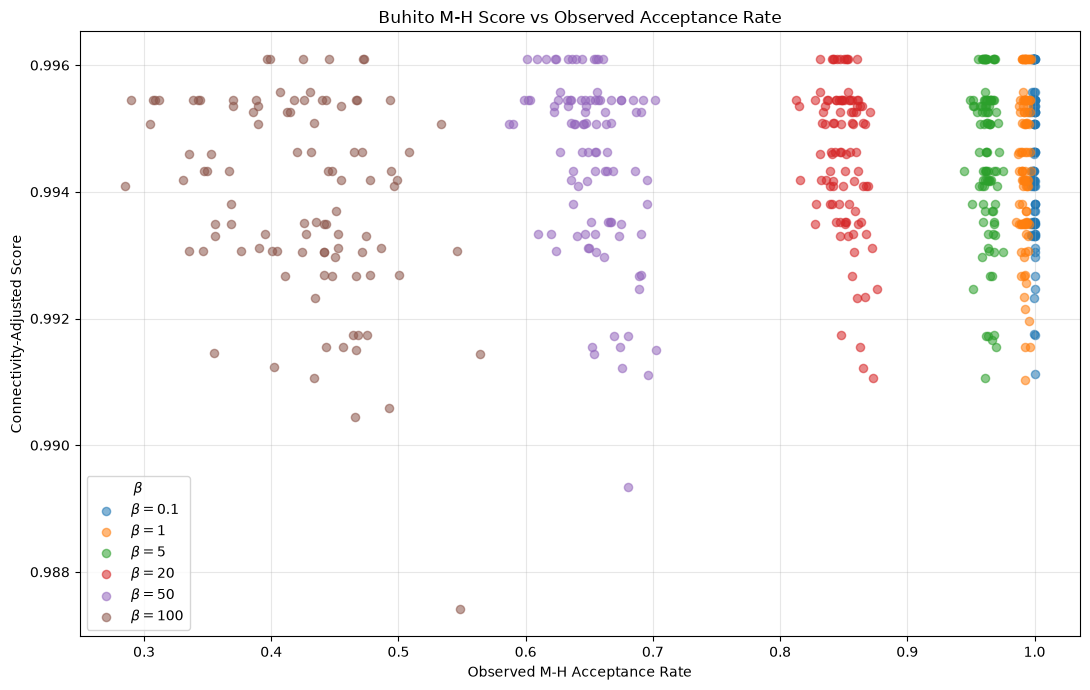

In [ ]:
beta_summary_df = (
    mh_results_df.groupby("Beta", as_index=False)
    .agg(
        N=("Adjusted Score", "count"),
        Mean_Acceptance_Rate=("Acceptance Rate", "mean"),
        Std_Acceptance_Rate=("Acceptance Rate", "std"),
        Mean_Adjusted_Score=("Adjusted Score", "mean"),
        Std_Adjusted_Score=("Adjusted Score", "std"),
        Min_Adjusted_Score=("Adjusted Score", "min"),
        Max_Adjusted_Score=("Adjusted Score", "max"),
    )
)

display(beta_summary_df)

fig, ax = plt.subplots(figsize=(11, 7))
for mh_beta in MH_BETAS:
    beta_data = mh_results_df[mh_results_df["Beta"] == mh_beta]
    ax.scatter(
        beta_data["Acceptance Rate"],
        beta_data["Adjusted Score"],
        s=35,
        alpha=0.55,
        label=rf"$\beta={mh_beta:g}$",
    )

ax.set_xlabel("Observed M-H Acceptance Rate")
ax.set_ylabel("Connectivity-Adjusted Score")
ax.set_title("Buhito M-H Score vs Observed Acceptance Rate")
ax.grid(alpha=0.3)
ax.legend(title=r"$\beta$")
plt.tight_layout()
plt.show()

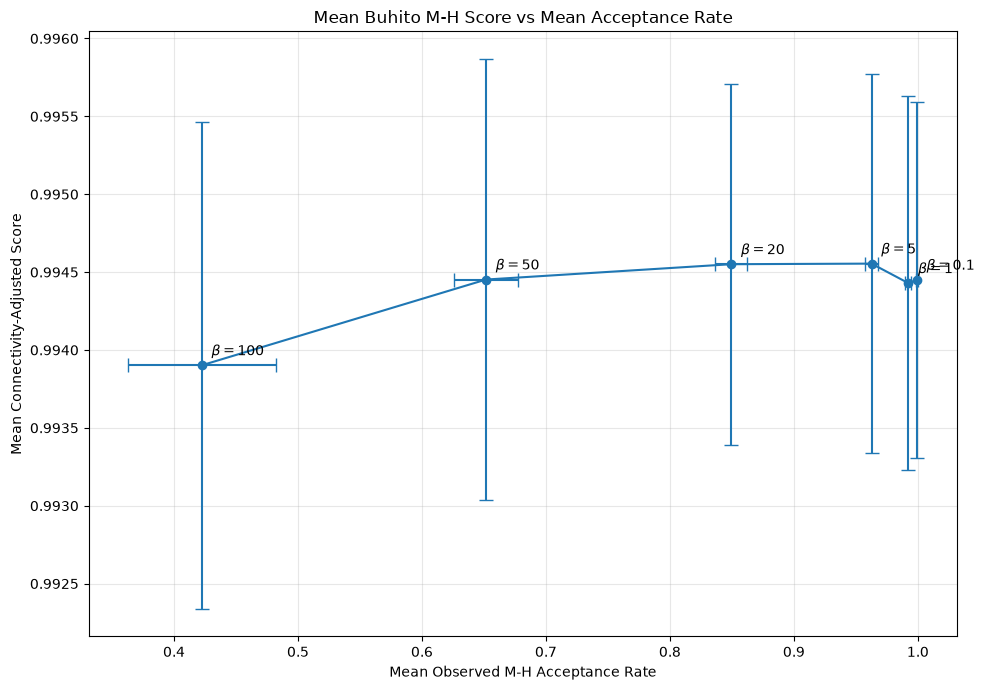

Pearson correlation = 0.105971


In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.errorbar(
    beta_summary_df["Mean_Acceptance_Rate"],
    beta_summary_df["Mean_Adjusted_Score"],
    xerr=beta_summary_df["Std_Acceptance_Rate"],
    yerr=beta_summary_df["Std_Adjusted_Score"],
    marker="o",
    capsize=5,
)

for _, row in beta_summary_df.iterrows():
    ax.annotate(
        rf"$\beta={row['Beta']:g}$",
        (row["Mean_Acceptance_Rate"], row["Mean_Adjusted_Score"]),
        xytext=(7, 7),
        textcoords="offset points",
    )

ax.set_xlabel("Mean Observed M-H Acceptance Rate")
ax.set_ylabel("Mean Connectivity-Adjusted Score")
ax.set_title("Mean Buhito M-H Score vs Mean Acceptance Rate")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

corr = mh_results_df[["Acceptance Rate", "Adjusted Score"]].corr().iloc[0, 1]
print(f"Pearson correlation = {corr:.6f}")

## 11. Repeat M-H experiment without single-atom contributions

The only change is the interpreter supplied to `PartitionOptimizer`. The Buhito features are unchanged; size-1 graphlet coefficients are set to zero by `PartitionInterpreter(remove_single_atom_contributions=True)`.

In [ ]:
interpreter_no_atoms.register_graph(large_mol, large_graph)

# Example single run; use the same loop above with interpreter_no_atoms
# if you want the full 100-initialization beta study.
optimizer_no_atoms = PartitionOptimizer(
    interpreter=interpreter_no_atoms,
    min_partitions=K_TO_PLOT,
    max_partitions=K_TO_PLOT,
    connectivity_weight=CONNECTIVITY_WEIGHT,
    disconnected_singleton_weight=DISCONNECTED_SINGLETON_WEIGHT,
)

no_atom_interp = optimizer_no_atoms.optimize_partition_metropolis_hastings(
    mol=large_mol,
    n_clusters=K_TO_PLOT,
    n_iterations=MH_ITERATIONS,
    beta=20.0,
    initialization=MH_INITIALIZATION,
    seed=42,
    verbose=False,
)

print("Raw score without size-1 graphlet contributions:", no_atom_interp.score)
print(
    "Adjusted score:",
    connectivity_adjusted_score(
        mol=large_mol,
        interpretation=no_atom_interp,
        connectivity_weight=CONNECTIVITY_WEIGHT,
        disconnected_singleton_weight=DISCONNECTED_SINGLETON_WEIGHT,
    ),
)

Raw score without size-1 graphlet contributions: 0.9679328235761114
Adjusted score: 0.9679328235761114


## 12. Buhito migration checklist

The notebook should no longer contain any of the following MinervaChem-only references:

```python
from minervachem ...
GraphletFingerprinter
FingerprintFeaturizer
HierarchicalResidualModel
GraphletDAG
draw_projected_coefs
draw_projected_coefs_with_partitions
featurizer.fingerprinter
interpreter.is_minervachem
```

For partition analysis, use this pattern:

```python
mol = row["mol"]
graph = row["graph"]
interpreter.register_graph(mol, graph)
interpretation = interpreter.compute_partition_contributions(mol, partition)
```

For visualization, use:

```python
draw_partition_interpretations(
    mols=mol,
    interpretations=interpretation,
)
```